In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

In [3]:
from Compression.Benchmarks.MOPED import moped
from Compression.compressors import IBCompressor
from Compression.conditional_prob_models import ConditionalKDE, ConditionalNormalizingFlow
from Compression.ib import IB, Bounds
from Compression.mine import Mine
from Compression.tuba import TUBA, DV_with_Jensen

from ModelEvaluation.posterior_comparison import evaluate_posterior_covariance

from SupernovaDataset.config import DATAPOINT_SIZE, DATA_VARIANCE_SCALE, LOAD_DATASET
from SupernovaDataset.config import NUM_TRAIN, NUM_TEST, LATENT_SIZE
from SupernovaDataset.dataset_creation import create_torch_supernovae_dataset, create_synthetic_supernovae_dataset


In [4]:
bounds = [
    Bounds(name="BA_KDE", cond_prob_model_class=ConditionalKDE, **{"init_std": 1, "num_kde_points": 5}),
    # Bounds(name="BA_NF", cond_prob_model_class=ConditionalNormalizingFlow, **{"num_flows": 64}),
    Bounds(name="DV", cond_prob_model_class=Mine, **{"y_dim": 1, "z_dim": LATENT_SIZE, "alpha": 0e0, "hidden_dim": 20}),
    # Bounds(name="DV_with_Jensen", cond_prob_model_class=DV_with_Jensen, **{"y_dim": 1, "z_dim": LATENT_SIZE, "hidden_dim": 5}),
    Bounds(name="MINE", cond_prob_model_class=Mine, **{"y_dim": 1, "z_dim": LATENT_SIZE, "alpha": 1e-1, "hidden_dim": 5}),
    # Bounds(name="TUBA", cond_prob_model_class=TUBA, **{"y_dim": 1, "z_dim": LATENT_SIZE, "hidden_dim": 5}),
    Bounds(name="NWJ", cond_prob_model_class=TUBA, **{"y_dim": 1, "z_dim": LATENT_SIZE, "hidden_dim": 10, "a": lambda z: torch.tensor(np.exp(1.0), device=device)})
]

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Running on device:", device)

Running on device: cuda


## Train MOPED

In [6]:
cov = np.eye(DATAPOINT_SIZE) * DATA_VARIANCE_SCALE**2

def estimator_given_theta(theta):
    _, data, _, _ = create_synthetic_supernovae_dataset(1, theta, data_var=0.)
    # print(data.shape)
    # return 10**(-0.4*data[0, :])
    return data[0, :]
moped_fid_val = np.array([70.0**2])

b, F, d = moped(moped_fid_val, cov, estimator_given_theta)
def moped_model(data):
    if (type(data) != np.ndarray):
        data = data# .detach().cpu().numpy()
    return data[:, :DATAPOINT_SIZE] @ b.T

Creating sample: 1 of 1
Creating sample: 1 of 1
Creating sample: 1 of 1
(1, 100)


## Train IBs

### Training data

In [7]:
train_sims_data, test_sims_data, _ = create_torch_supernovae_dataset(NUM_TRAIN, NUM_TEST, tau=0.)

train_sims_data = train_sims_data.to(device)
test_sims_data = test_sims_data.to(device)

Creating sample: 10000 of 10000
Creating sample: 50000 of 50000


In [8]:
class Compressor(nn.Module):
    def __init__(self, input_size=DATAPOINT_SIZE, latent_size=LATENT_SIZE):
        super(Compressor, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            
            nn.Linear(32, 2*latent_size)
        )

    def forward(self, x):
        return self.encoder(x)

In [9]:
compressors = [Compressor() for _ in bounds]
ib_models = [
    IB(
        encoder=IBCompressor(encoder=compressor, x_dim=DATAPOINT_SIZE, z_dim=LATENT_SIZE),
        cond_prob_model=bound.cond_prob_model(**bound.cond_prob_model_kwargs),
        beta=1e-1,
        reg_weight=4e-2,
        reg_type=0,
        optim_func=torch.optim.Adam,
        lr=1e-4
        ).to(device)
    for compressor, bound in zip(compressors, bounds)
]

h02s = train_sims_data[:, -1:]
h02_norm = (h02s - h02s.mean()) / h02s.std()

Training with bound: BA_KDE
Epoch 1: Loss=3.0969, log_q=-3.0102,, reg. loss=0.0349, beta * KL=0.5174
Epoch 10: Loss=3.0703, log_q=-2.9907,, reg. loss=0.0224, beta * KL=0.5720
Epoch 20: Loss=3.0495, log_q=-2.9700,, reg. loss=0.0223, beta * KL=0.5712
Epoch 30: Loss=3.0379, log_q=-2.9582,, reg. loss=0.0224, beta * KL=0.5723
Epoch 40: Loss=3.0234, log_q=-2.9439,, reg. loss=0.0222, beta * KL=0.5724
Epoch 50: Loss=3.0120, log_q=-2.9324,, reg. loss=0.0222, beta * KL=0.5733
Epoch 60: Loss=2.9999, log_q=-2.9199,, reg. loss=0.0222, beta * KL=0.5783
Epoch 70: Loss=2.9873, log_q=-2.9066,, reg. loss=0.0220, beta * KL=0.5871
Epoch 80: Loss=2.9757, log_q=-2.8922,, reg. loss=0.0210, beta * KL=0.6251
Epoch 90: Loss=2.9722, log_q=-2.8767,, reg. loss=0.0200, beta * KL=0.7546
Epoch 100: Loss=2.9762, log_q=-2.8719,, reg. loss=0.0214, beta * KL=0.8291


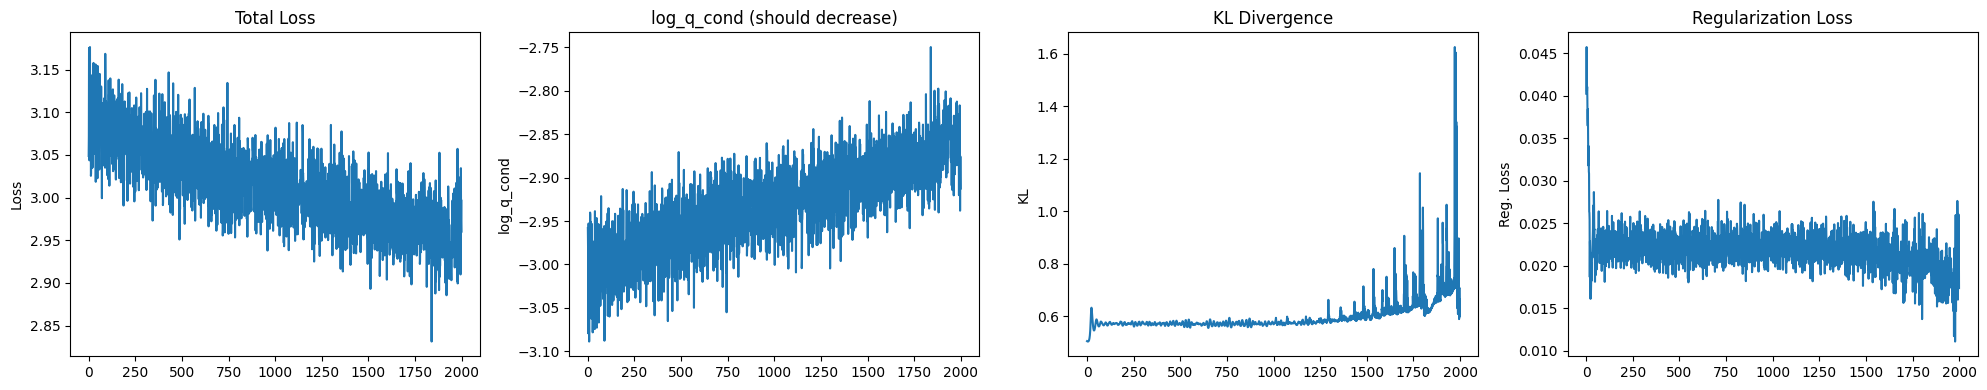

Training with bound: DV
Epoch 1: Loss=2.3159, log_q=-2.2306,, reg. loss=0.0340, beta * KL=0.5127
Epoch 10: Loss=1.2625, log_q=-1.1827,, reg. loss=0.0226, beta * KL=0.5722
Epoch 20: Loss=0.7821, log_q=-0.7018,, reg. loss=0.0214, beta * KL=0.5889
Epoch 30: Loss=0.4615, log_q=-0.3113,, reg. loss=0.0061, beta * KL=1.4402
Epoch 40: Loss=0.1869, log_q=0.0055,, reg. loss=0.0052, beta * KL=1.8725
Epoch 50: Loss=0.0657, log_q=0.1721,, reg. loss=0.0039, beta * KL=2.3401
Epoch 60: Loss=-0.0380, log_q=0.2636,, reg. loss=0.0082, beta * KL=2.1739
Epoch 70: Loss=-0.1012, log_q=0.3455,, reg. loss=0.0085, beta * KL=2.3581
Epoch 80: Loss=-0.0566, log_q=0.4035,, reg. loss=0.0084, beta * KL=3.3852
Epoch 90: Loss=-0.2405, log_q=0.4747,, reg. loss=0.0096, beta * KL=2.2462
Epoch 100: Loss=-0.3067, log_q=0.5576,, reg. loss=0.0124, beta * KL=2.3845


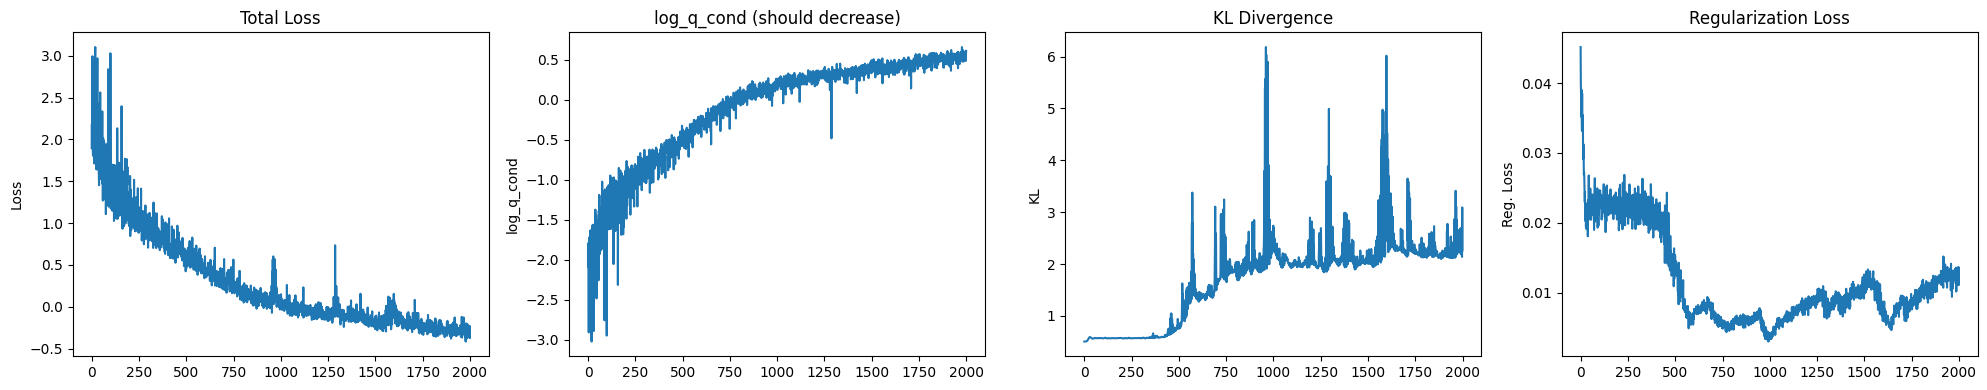

Training with bound: MINE
Epoch 1: Loss=1.3100, log_q=-1.2252,, reg. loss=0.0326, beta * KL=0.5213
Epoch 10: Loss=0.9926, log_q=-0.9127,, reg. loss=0.0224, beta * KL=0.5748
Epoch 20: Loss=0.2362, log_q=0.0895,, reg. loss=0.0009, beta * KL=3.2478
Epoch 30: Loss=-0.0813, log_q=0.3867,, reg. loss=0.0019, beta * KL=3.0348
Epoch 40: Loss=-0.1924, log_q=0.4822,, reg. loss=0.0046, beta * KL=2.8522
Epoch 50: Loss=-0.2641, log_q=0.5529,, reg. loss=0.0062, beta * KL=2.8264
Epoch 60: Loss=-0.3832, log_q=0.6473,, reg. loss=0.0092, beta * KL=2.5479
Epoch 70: Loss=-0.4318, log_q=0.7069,, reg. loss=0.0101, beta * KL=2.6508
Epoch 80: Loss=-0.4978, log_q=0.7609,, reg. loss=0.0123, beta * KL=2.5080
Epoch 90: Loss=-0.5457, log_q=0.8119,, reg. loss=0.0124, beta * KL=2.5374
Epoch 100: Loss=-0.5709, log_q=0.8506,, reg. loss=0.0139, beta * KL=2.6578


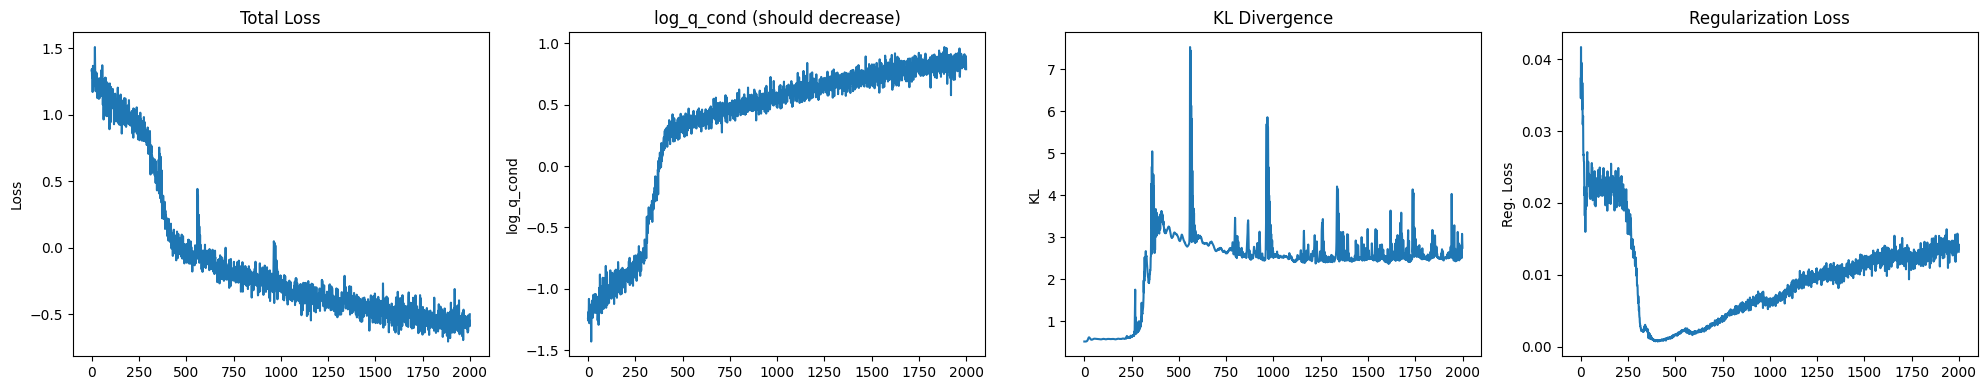

Training with bound: NWJ
Epoch 1: Loss=0.5158, log_q=-0.4330,, reg. loss=0.0295, beta * KL=0.5329
Epoch 10: Loss=0.4499, log_q=-0.3701,, reg. loss=0.0225, beta * KL=0.5729
Epoch 20: Loss=0.3917, log_q=-0.3126,, reg. loss=0.0219, beta * KL=0.5722
Epoch 30: Loss=0.3368, log_q=-0.2576,, reg. loss=0.0220, beta * KL=0.5717
Epoch 40: Loss=0.2802, log_q=-0.2012,, reg. loss=0.0222, beta * KL=0.5684
Epoch 50: Loss=0.2196, log_q=-0.1399,, reg. loss=0.0225, beta * KL=0.5717
Epoch 60: Loss=0.1611, log_q=-0.0818,, reg. loss=0.0224, beta * KL=0.5690
Epoch 70: Loss=0.1223, log_q=-0.0434,, reg. loss=0.0219, beta * KL=0.5704
Epoch 80: Loss=0.1034, log_q=-0.0240,, reg. loss=0.0220, beta * KL=0.5729
Epoch 90: Loss=0.0972, log_q=-0.0177,, reg. loss=0.0221, beta * KL=0.5736
Epoch 100: Loss=0.0917, log_q=-0.0123,, reg. loss=0.0217, beta * KL=0.5762


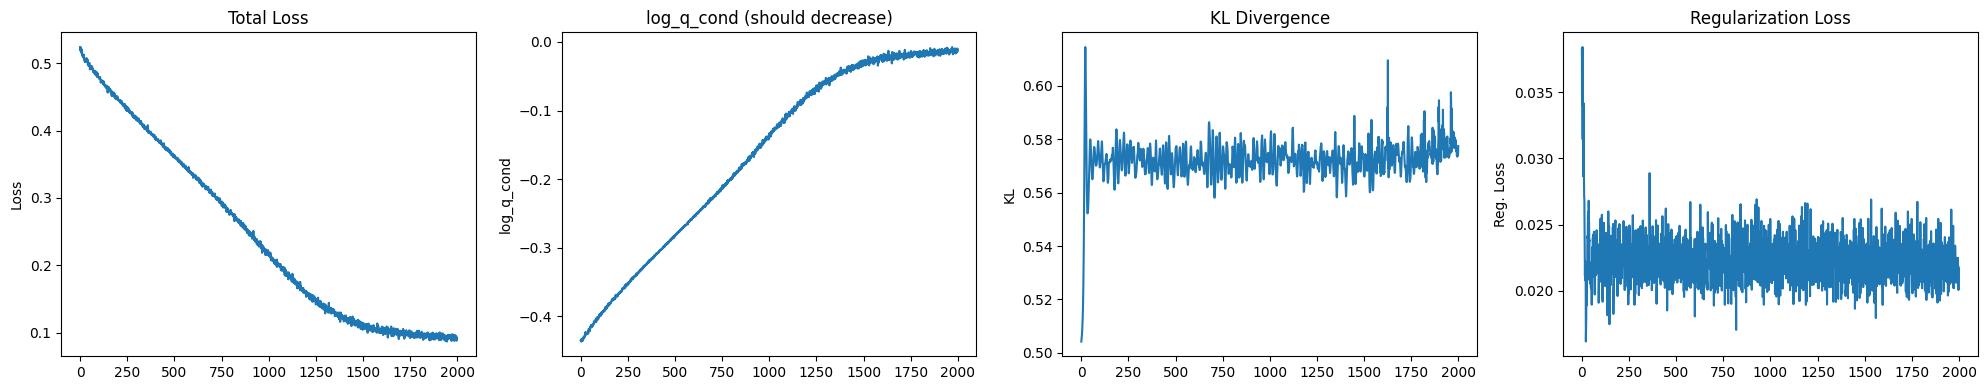

In [10]:
for i, bound in enumerate(bounds):
    print(f"Training with bound: {bound.name}")
    ib_model = ib_models[i]
    ib_model.train(
        x_train=train_sims_data[:, :DATAPOINT_SIZE],
        y_train=h02_norm,
        nepochs=100,
        batch_size=512,
        print_losses=True
    )
    assert not np.isnan(ib_model.full_losses[-1]), "Total loss is NaN. Check the model and training process."

## Sweeping over taus

In [13]:
taus = np.linspace(0.0, 1, 15)
NUM_BINS = 21

In [19]:
moped_scores = []
moped_score_errors = []
mi_bound_scores = [[] for _ in bounds]
mi_bound_score_errors = [[] for _ in bounds]
for tau in taus:
    # Generate dataset with current tau
    test_sims_data, _, _ = create_torch_supernovae_dataset(NUM_TRAIN*40, 1, tau=tau, print_status=False)
    # Evaluate MOPED compression/reconstruction score


    moped_sigma, moped_std_error, _, _ = evaluate_posterior_covariance(
        moped_model,
        test_sims_data[:, :DATAPOINT_SIZE],
        test_sims_data[:, -1:],
        plot_results=False,
        print_results=False,
        num_bins=NUM_BINS
    )
    print(moped_sigma, moped_std_error.shape, moped_std_error.mean())

    moped_sigma += 1e-6  # Avoid division by zero

    moped_scores.append(1.0 / (moped_sigma**2))
    moped_score_errors.append(2.0 * moped_std_error.mean() / (moped_sigma ** 3))

    for i, bound in enumerate(bounds):
        ib_model = ib_models[i]
        # Evaluate Neural MI Bound compression score
        mi_bound_sigma, mi_bound_std_error, _, _  = evaluate_posterior_covariance(
            ib_model,
            test_sims_data[:, :DATAPOINT_SIZE].to(device),
            test_sims_data[:, -1:].to(device),
            plot_results=False,
            print_results=False,
            num_bins=NUM_BINS
        )
        mi_bound_scores[i].append(1.0 / (mi_bound_sigma**2))
        mi_bound_score_errors[i].append(2.0 * mi_bound_std_error.mean() / (mi_bound_sigma ** 3))
        print(f"Tau {tau:<10.3f} Evaluated: {bound.name}: score={mi_bound_scores[i][-1]:.3f}+/-{mi_bound_score_errors[i][-1]:.3f}")

    print(f"Tau {tau:<10.3f}: MOPED score = {moped_scores[-1]:.3f}+/-{moped_score_errors[-1]:.3f}")

C:\Users\srish\AppData\Local\Temp\ipykernel_21392\3665724087.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return data[:, :DATAPOINT_SIZE] @ b.T


7.612441203497828 () 0.01861939644626257
Tau 0.000      Evaluated: BA_KDE: score=0.003+/-0.000
Tau 0.000      Evaluated: DV: score=0.016+/-0.000
Tau 0.000      Evaluated: MINE: score=0.016+/-0.000
Tau 0.000      Evaluated: NWJ: score=0.002+/-0.000
Tau 0.000     : MOPED score = 0.017+/-0.000
23.26048764607167 () 0.05684176865176529
Tau 0.071      Evaluated: BA_KDE: score=0.002+/-0.000
Tau 0.071      Evaluated: DV: score=0.002+/-0.000
Tau 0.071      Evaluated: MINE: score=0.002+/-0.000
Tau 0.071      Evaluated: NWJ: score=0.002+/-0.000
Tau 0.071     : MOPED score = 0.002+/-0.000
24.414439162042452 () 0.05961255194228068
Tau 0.143      Evaluated: BA_KDE: score=0.002+/-0.000
Tau 0.143      Evaluated: DV: score=0.002+/-0.000
Tau 0.143      Evaluated: MINE: score=0.002+/-0.000
Tau 0.143      Evaluated: NWJ: score=0.002+/-0.000
Tau 0.143     : MOPED score = 0.002+/-0.000
24.778071721389153 () 0.06042201821660676
Tau 0.214      Evaluated: BA_KDE: score=0.002+/-0.000
Tau 0.214      Evaluated: D

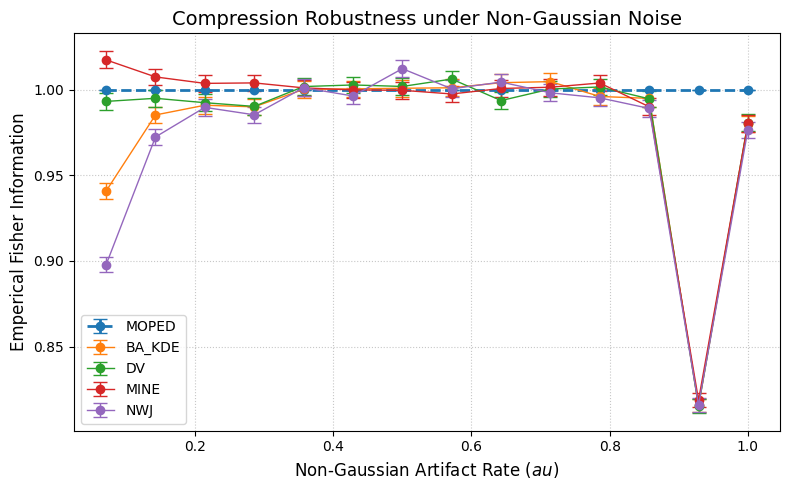

In [18]:
plt.figure(figsize=(8, 5))
moped_scores = np.array(moped_scores)

# Use fmt='-o' to draw a solid line (-) with circle markers (o)
# Matplotlib will automatically use the same color for the line, marker, and error bars
plt.errorbar(
    taus[1:], 
    moped_scores[1:]/moped_scores[1:], 
    yerr=moped_score_errors[1:], 
    fmt='--o', 
    capsize=5, 
    label="MOPED", 
    linewidth=2
)

for i, bound in enumerate(bounds):
    plt.errorbar(
        taus[1:], 
        np.array(mi_bound_scores[i][1:])/moped_scores[1:],
        yerr=np.array(mi_bound_score_errors[i][1:])/moped_scores[1:], 
        fmt='-o', 
        capsize=5, 
        label=f"{bound.name}",
        linewidth=1
    )
    # if i == 1:
    #     break

# Updated the labels to match the metrics we discussed!
plt.xlabel(f"Non-Gaussian Artifact Rate ($\tau$)", fontsize=12)
plt.ylabel("Emperical Fisher Information", fontsize=12)

# plt.yscale('log')
# plt.ylim([0.98, 1.015])
# plt.ylim([0.75e-1, 3.1e-1])
# plt.ylim([1.55e-3, 1.67e-3])

plt.title("Compression Robustness under Non-Gaussian Noise", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\srish\AppData\Local\Temp\ipykernel_23632\1065325328.py:16: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim([0, 2e-3])


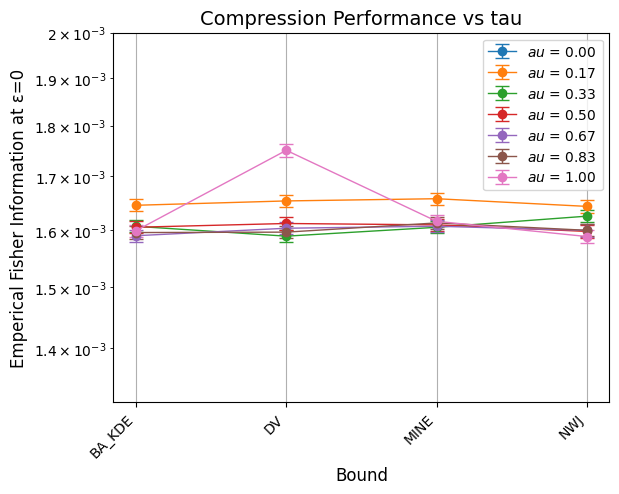

In [ ]:
FI_at_eps = [[mi_bound_scores[i][j] for i in range(len(bounds))] for j in range(len(taus))]
FI_at_eps_errors = [[mi_bound_score_errors[i][j] for i in range(len(bounds))] for j in range(len(taus))]
for j in range(len(taus)):
    plt.errorbar(
            [bound.name for bound in bounds],
            y=FI_at_eps[j], 
            yerr=FI_at_eps_errors[j],
            fmt='-o', 
            capsize=5,
            label=f"$\tau$ = {taus[j]:.2f}",
            linewidth=1
        )
    # if j == 3:
    #     break
plt.yscale('log')
plt.ylim([0, 2e-3])
plt.xlabel("Bound", fontsize=12)
plt.xticks(ticks=[bound.name for bound in bounds], rotation=45, ha='right', fontsize=10)
plt.ylabel("Emperical Fisher Information at \u03B5=0", fontsize=12)
plt.title("Compression Performance vs tau", fontsize=14)
plt.legend()
plt.grid()
plt.show()